In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PowerTransformer
)
from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv("../datasets/overcrowding_prediction_dataset.csv")
df.drop(columns=['Prison_ID'],inplace=True)

# Feature Engineering
adding :

1.Current_Occupancy_Rate

2.Average_Daily_Admissions 

3.Monthly_Growth_Rate 

In [3]:
df["Current_Occupancy_Rate"]=(df['Current_Occupancy'] / df['Capacity'])*100
df["Average_Daily_Admissions"]=df['Admissions_Last_30_Days'] / 30
df["Monthly_Growth_Rate"]=((df["Current_Occupancy"] - df["Occupancy_30_Days_Ago"])/ df["Occupancy_30_Days_Ago"])*100

In [4]:
df

,Prison_Type,Security_Level,Capacity,Number_of_Blocks,Current_Occupancy,Admissions_Last_7_Days,Admissions_Last_30_Days,Pending_Admissions,Releases_Last_7_Days,Releases_Last_30_Days,...,Occupancy_7_Days_Ago,Occupancy_30_Days_Ago,Occupancy_60_Days_Ago,Occupancy_90_Days_Ago,Occupancy_30_Days,Occupancy_60_Days,Occupancy_90_Days,Current_Occupancy_Rate,Average_Daily_Admissions,Monthly_Growth_Rate
0,Maximum Security,High,800,8,493,1,10,2,1,9,...,486,502,518,532,480,478,446,61.625000,0.333333,-1.792829
1,Maximum Security,High,1320,10,857,5,20,1,10,30,...,837,834,835,838,824,822,822,64.924242,0.666667,2.757794
2,Remand,Low,215,1,185,1,3,1,1,2,...,199,198,189,190,191,196,136,86.046512,0.100000,-6.565657
3,Minimum Security,Low,1554,7,1359,6,33,5,8,30,...,1350,1339,1324,1327,1353,1360,1336,87.451737,1.100000,1.493652
4,Minimum Security,Low,1536,8,887,3,21,3,7,25,...,881,869,869,861,871,877,867,57.747396,0.700000,2.071346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,Minimum Security,Low,328,2,207,1,11,2,1,3,...,212,209,196,180,204,184,161,63.109756,0.366667,-0.956938
19996,Minimum Security,Low,2230,10,1603,8,34,6,15,47,...,1630,1614,1594,1575,1612,1623,1633,71.883408,1.133333,-0.681537
19997,Juvenile,High,192,1,145,2,6,2,1,3,...,144,127,110,104,131,100,122,75.520833,0.200000,14.173228
19998,Remand,Medium,1266,6,1181,10,36,8,9,38,...,1162,1172,1189,1211,1169,1158,1122,93.285940,1.200000,0.767918


In [5]:
df.describe()

,Capacity,Number_of_Blocks,Current_Occupancy,Admissions_Last_7_Days,Admissions_Last_30_Days,Pending_Admissions,Releases_Last_7_Days,Releases_Last_30_Days,Upcoming_Releases_30_Days,Upcoming_Releases_60_Days,...,Occupancy_7_Days_Ago,Occupancy_30_Days_Ago,Occupancy_60_Days_Ago,Occupancy_90_Days_Ago,Occupancy_30_Days,Occupancy_60_Days,Occupancy_90_Days,Current_Occupancy_Rate,Average_Daily_Admissions,Monthly_Growth_Rate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,903.568100,5.513200,691.462600,4.267400,19.879550,3.019550,3.935050,18.308800,25.360000,42.319200,...,690.342700,690.693100,691.011100,691.192750,689.578900,690.969550,680.332950,76.390568,0.662652,0.575683
std,557.232041,2.864932,448.061653,3.378131,13.311232,2.662503,3.147352,12.386647,13.144407,14.902762,...,448.373517,448.407295,448.564078,448.910004,451.370807,463.388275,470.994697,12.427079,0.443708,6.729912
min,80.000000,1.000000,47.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,...,19.000000,16.000000,13.000000,1.000000,22.000000,0.000000,0.000000,54.255319,0.000000,-37.500000
25%,449.500000,3.000000,334.000000,2.000000,9.000000,1.000000,1.000000,8.000000,16.000000,32.000000,...,332.000000,333.000000,333.000000,333.750000,329.000000,321.000000,304.000000,65.714286,0.300000,-1.506828
50%,820.000000,6.000000,610.000000,3.000000,17.000000,2.000000,3.000000,16.000000,23.000000,41.000000,...,609.000000,609.500000,609.000000,609.000000,608.000000,607.000000,595.500000,76.262626,0.566667,0.083718
75%,1274.000000,8.000000,967.000000,6.000000,28.000000,4.000000,6.000000,26.000000,33.000000,52.000000,...,966.000000,968.000000,967.250000,968.000000,967.000000,976.250000,971.000000,87.023735,0.933333,1.843318
max,2490.000000,10.000000,2438.000000,23.000000,85.000000,18.000000,24.000000,79.000000,90.000000,111.000000,...,2446.000000,2441.000000,2429.000000,2421.000000,2455.000000,2490.000000,2490.000000,97.959184,2.833333,250.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Prison_Type                 20000 non-null  str    
 1   Security_Level              20000 non-null  str    
 2   Capacity                    20000 non-null  int64  
 3   Number_of_Blocks            20000 non-null  int64  
 4   Current_Occupancy           20000 non-null  int64  
 5   Admissions_Last_7_Days      20000 non-null  int64  
 6   Admissions_Last_30_Days     20000 non-null  int64  
 7   Pending_Admissions          20000 non-null  int64  
 8   Releases_Last_7_Days        20000 non-null  int64  
 9   Releases_Last_30_Days       20000 non-null  int64  
 10  Upcoming_Releases_30_Days   20000 non-null  int64  
 11  Upcoming_Releases_60_Days   20000 non-null  int64  
 12  Upcoming_Releases_90_Days   20000 non-null  int64  
 13  Transfers_In_Last_30_Days   20000 non-null

In [7]:
df.drop(columns=['Security_Level','Prison_Type']).skew()

Capacity                      0.600194
Number_of_Blocks             -0.006449
Current_Occupancy             0.788032
Admissions_Last_7_Days        1.382363
Admissions_Last_30_Days       0.917865
Pending_Admissions            1.200279
Releases_Last_7_Days          1.415287
Releases_Last_30_Days         0.898516
Upcoming_Releases_30_Days     0.756893
Upcoming_Releases_60_Days     0.501793
Upcoming_Releases_90_Days     0.277117
Transfers_In_Last_30_Days     0.965618
Transfers_Out_Last_30_Days    0.974652
Pending_Transfers_In          1.245840
Pending_Transfers_Out         1.355551
Average_Remaining_Sentence    1.028335
Median_Remaining_Sentence     1.012610
Occupancy_7_Days_Ago          0.786873
Occupancy_30_Days_Ago         0.786499
Occupancy_60_Days_Ago         0.785158
Occupancy_90_Days_Ago         0.783311
Occupancy_30_Days             0.788754
Occupancy_60_Days             0.789175
Occupancy_90_Days             0.787989
Current_Occupancy_Rate        0.011131
Average_Daily_Admissions 

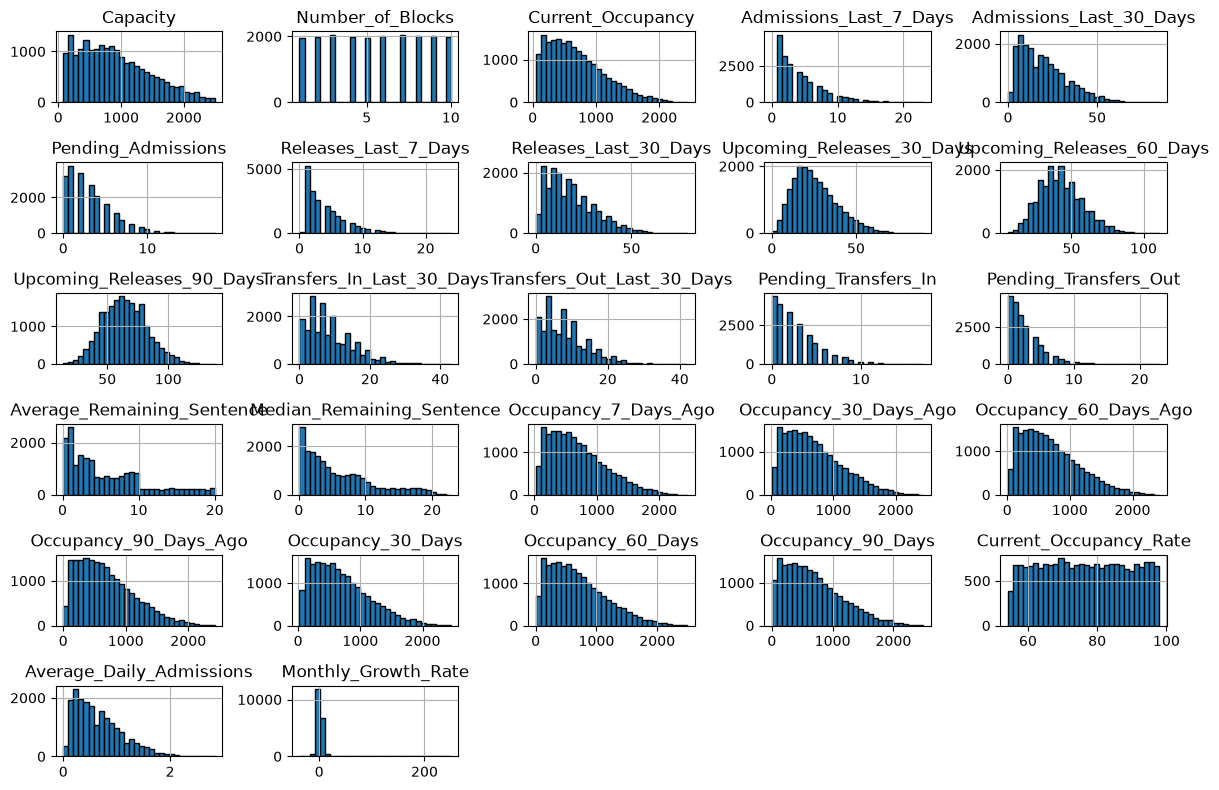

In [8]:
df.hist(
    figsize=(12, 8),
    bins=30,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

In [9]:
df["Monthly_Growth_Rate"].describe(percentiles=[0.95, 0.99, 0.999])

count    20000.000000
mean         0.575683
std          6.729912
min        -37.500000
95%          8.274313
99%         22.342511
99.9%       65.715238
max        250.000000
Name: Monthly_Growth_Rate, dtype: float64

In [10]:
df

,Prison_Type,Security_Level,Capacity,Number_of_Blocks,Current_Occupancy,Admissions_Last_7_Days,Admissions_Last_30_Days,Pending_Admissions,Releases_Last_7_Days,Releases_Last_30_Days,...,Occupancy_7_Days_Ago,Occupancy_30_Days_Ago,Occupancy_60_Days_Ago,Occupancy_90_Days_Ago,Occupancy_30_Days,Occupancy_60_Days,Occupancy_90_Days,Current_Occupancy_Rate,Average_Daily_Admissions,Monthly_Growth_Rate
0,Maximum Security,High,800,8,493,1,10,2,1,9,...,486,502,518,532,480,478,446,61.625000,0.333333,-1.792829
1,Maximum Security,High,1320,10,857,5,20,1,10,30,...,837,834,835,838,824,822,822,64.924242,0.666667,2.757794
2,Remand,Low,215,1,185,1,3,1,1,2,...,199,198,189,190,191,196,136,86.046512,0.100000,-6.565657
3,Minimum Security,Low,1554,7,1359,6,33,5,8,30,...,1350,1339,1324,1327,1353,1360,1336,87.451737,1.100000,1.493652
4,Minimum Security,Low,1536,8,887,3,21,3,7,25,...,881,869,869,861,871,877,867,57.747396,0.700000,2.071346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,Minimum Security,Low,328,2,207,1,11,2,1,3,...,212,209,196,180,204,184,161,63.109756,0.366667,-0.956938
19996,Minimum Security,Low,2230,10,1603,8,34,6,15,47,...,1630,1614,1594,1575,1612,1623,1633,71.883408,1.133333,-0.681537
19997,Juvenile,High,192,1,145,2,6,2,1,3,...,144,127,110,104,131,100,122,75.520833,0.200000,14.173228
19998,Remand,Medium,1266,6,1181,10,36,8,9,38,...,1162,1172,1189,1211,1169,1158,1122,93.285940,1.200000,0.767918


In [11]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PowerTransformer
)

# -----------------------------
# Feature Lists
# -----------------------------

categorical_features = [
    "Prison_Type",
    "Security_Level"
]

numeric_features = [
    "Capacity",
    "Number_of_Blocks",
    "Current_Occupancy",

    "Admissions_Last_7_Days",
    "Admissions_Last_30_Days",
    "Pending_Admissions",

    "Releases_Last_7_Days",
    "Releases_Last_30_Days",
    "Upcoming_Releases_30_Days",
    "Upcoming_Releases_60_Days",
    "Upcoming_Releases_90_Days",

    "Transfers_In_Last_30_Days",
    "Transfers_Out_Last_30_Days",
    "Pending_Transfers_In",
    "Pending_Transfers_Out",

    "Average_Remaining_Sentence",
    "Median_Remaining_Sentence",

    "Occupancy_7_Days_Ago",
    "Occupancy_30_Days_Ago",
    "Occupancy_60_Days_Ago",
    "Occupancy_90_Days_Ago",

    "Current_Occupancy_Rate",
    "Average_Daily_Admissions",
    "Monthly_Growth_Rate"
]

# -----------------------------
# Numeric Pipeline
# -----------------------------
# No log transform.
# Yeo-Johnson handles positive and negative values.
# Then StandardScaler for KNN/SVR.

numeric_pipeline_with_log = Pipeline([
    ("yeojohnson", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])
numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# -----------------------------
# Full Preprocessor
# -----------------------------

preprocessor_with_log = ColumnTransformer([
    ("num", numeric_pipeline_with_log, numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [12]:
X = df.drop(columns=[
    "Occupancy_30_Days",
    "Occupancy_60_Days",
    "Occupancy_90_Days"
])
y = df[[
    "Occupancy_30_Days",
    "Occupancy_60_Days",
    "Occupancy_90_Days"
]]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
knn_model = Pipeline([
    ("preprocessor", preprocessor_with_log),
    ("model", KNeighborsRegressor())
])
knn_model.fit(X_train, y_train)
knn_model.score(X_test, y_test)


0.9813972401009877

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor_with_log),
    ("model", RandomForestRegressor(random_state=42))
])
rf_model.fit(X_train, y_train)
rf_model.score(X_test, y_test)

0.9984880318082107

In [16]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = Pipeline([
    ("preprocessor", preprocessor_with_log),
    ("model", GradientBoostingRegressor(random_state=42))
])
gb_model.fit(X_train, y_train)
gb_model.score(X_test, y_test)

ValueError: y should be a 1d array, got an array of shape (16000, 3) instead.

In [18]:
from xgboost import XGBRegressor
xgb_model = Pipeline([
    ("preprocessor", preprocessor_with_log),
    ("model", XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ))
])
xgb_model.fit(X_train, y_train)
xgb_model.score(X_test, y_test)

0.9984919428825378